# 1 Avec 10 itérations

## 1.1 Evolution du F1-score, Temps et RAM_MB des modèles sur 10 itérations

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

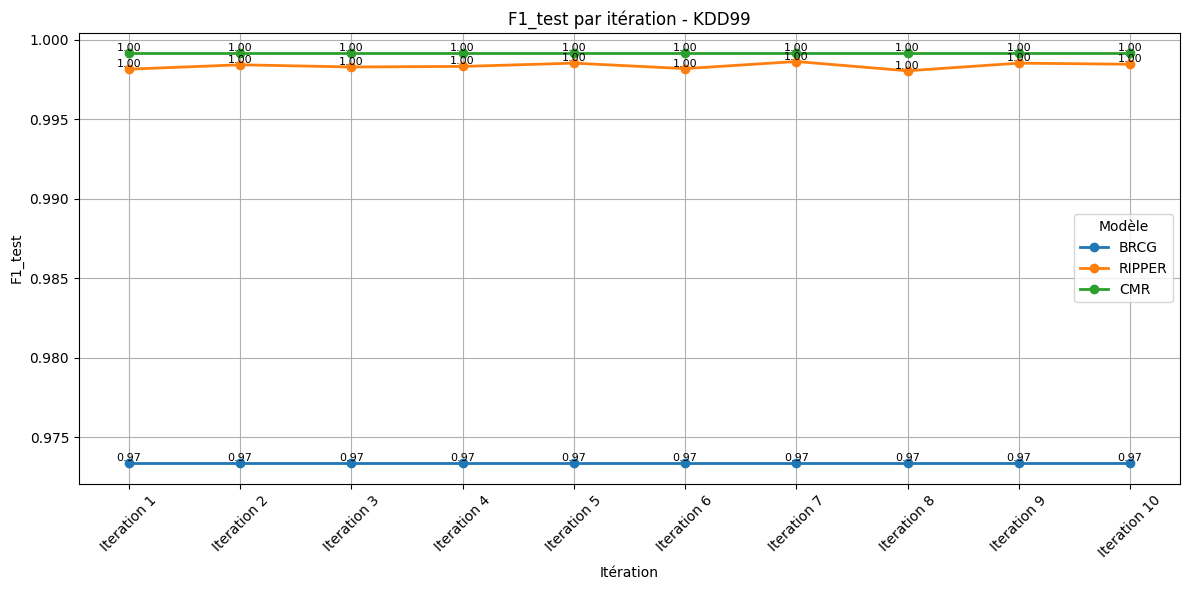

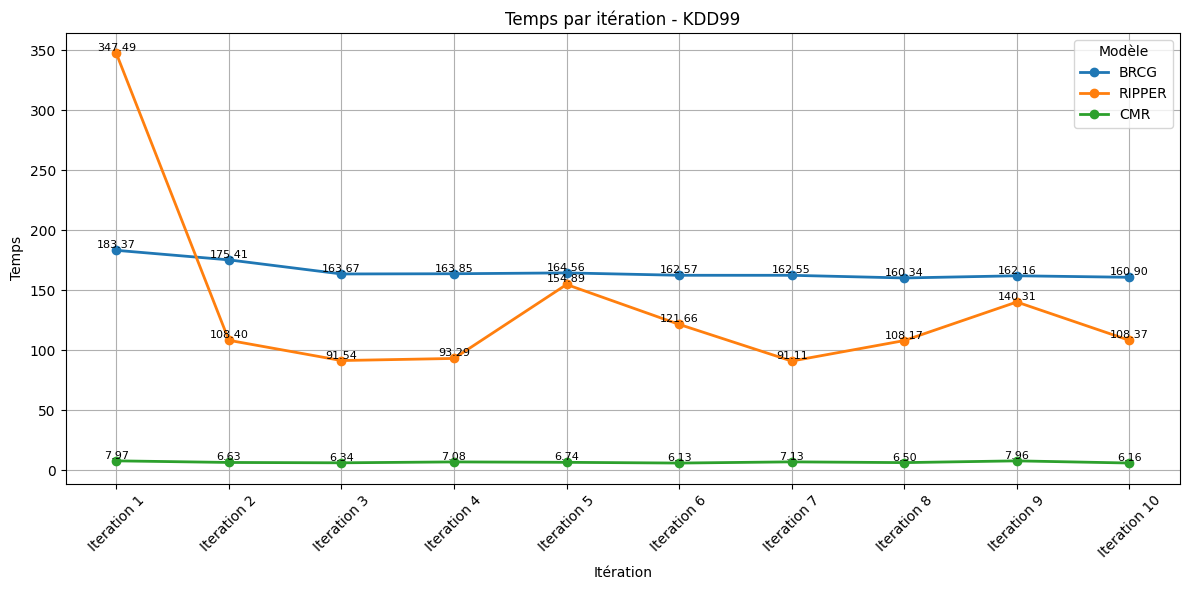

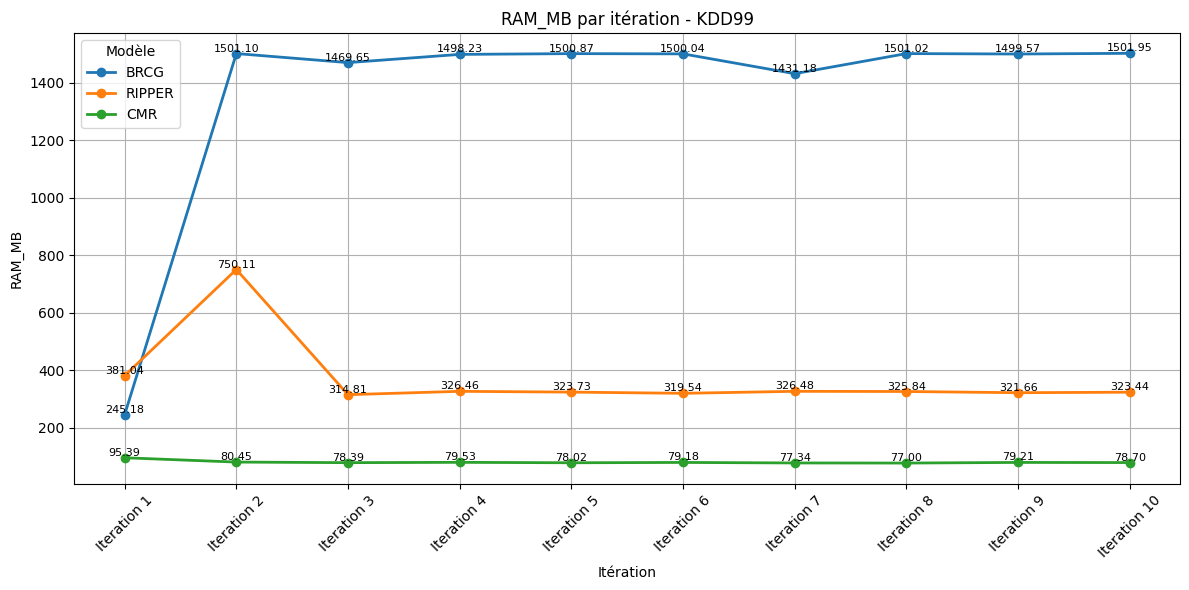

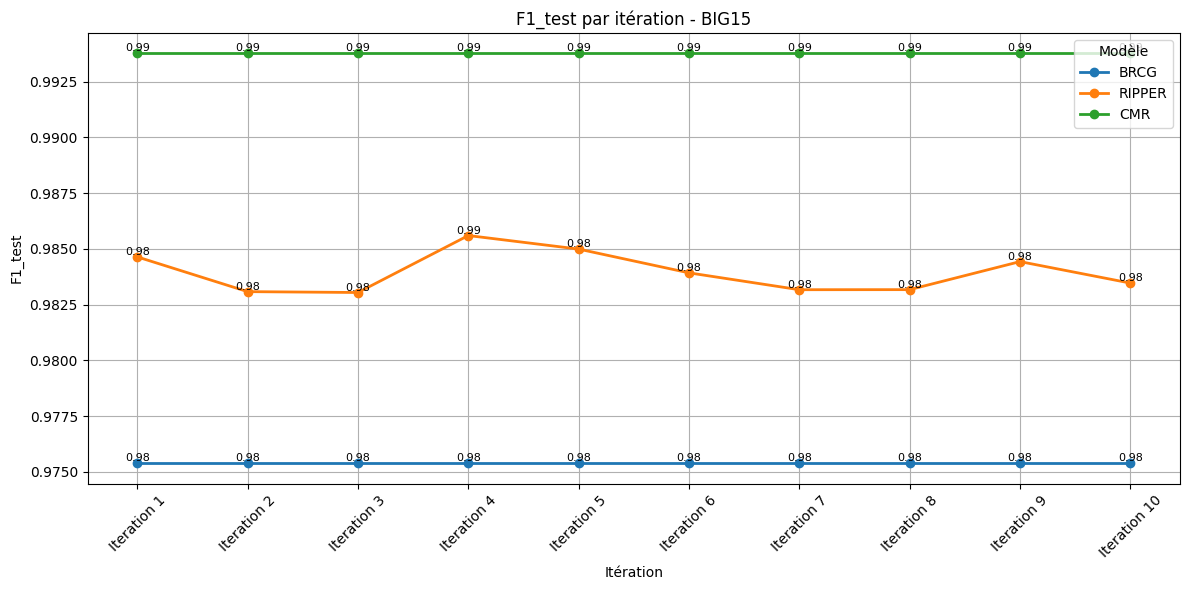

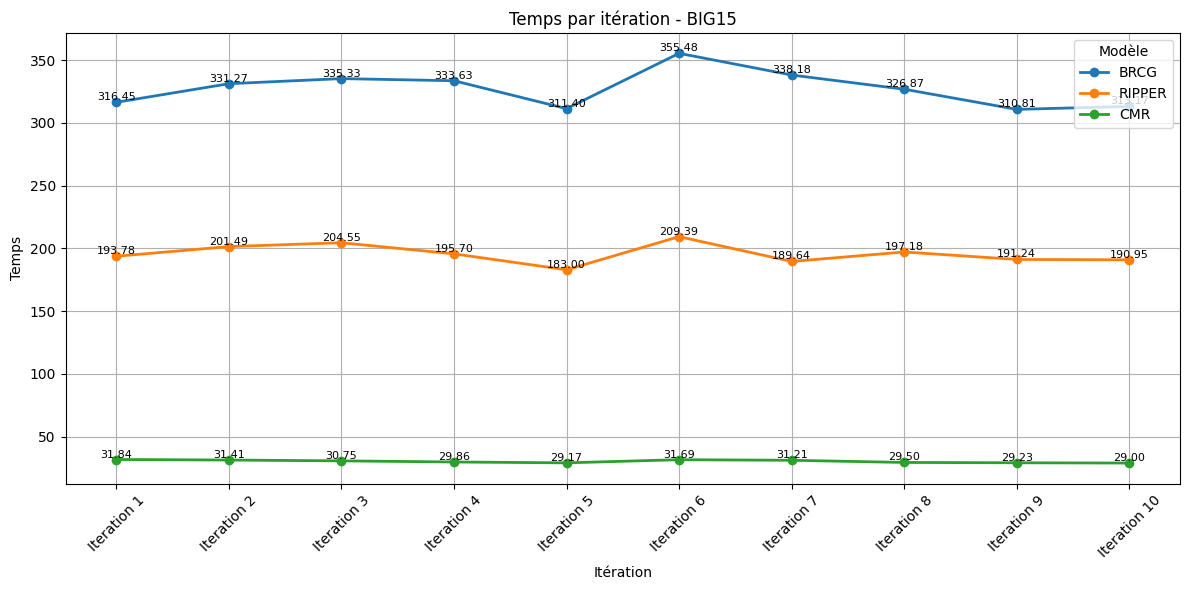

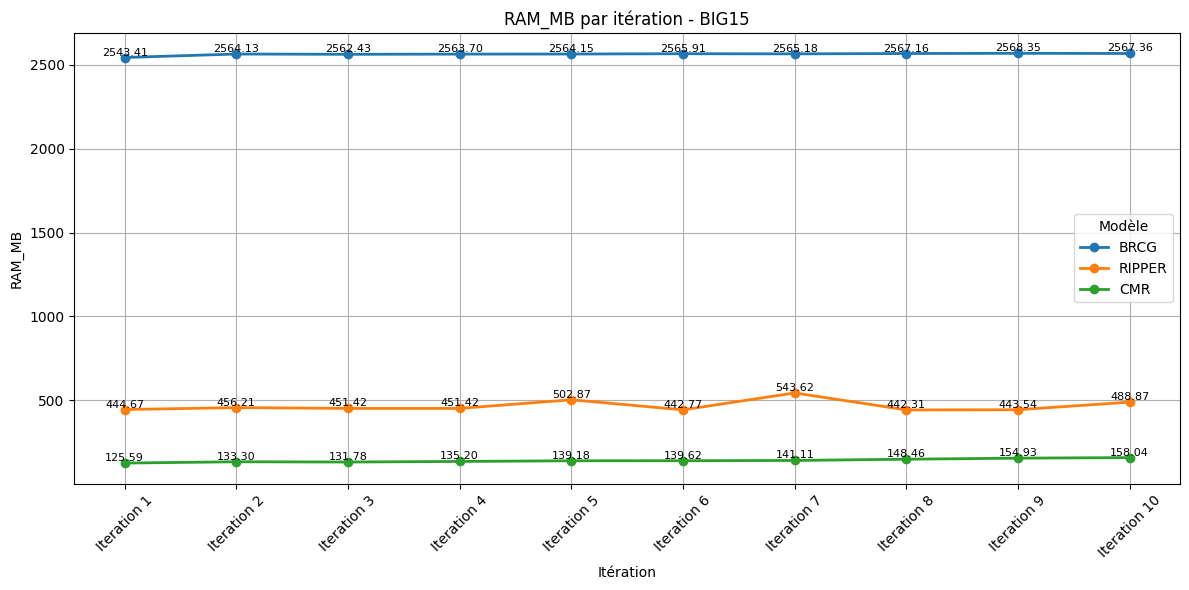

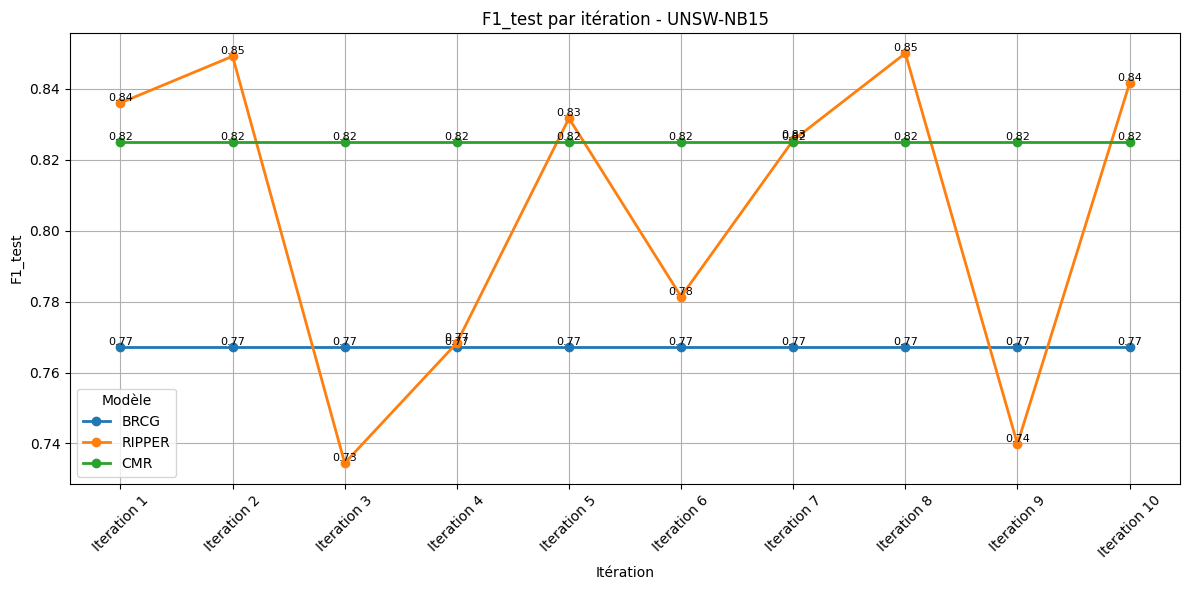

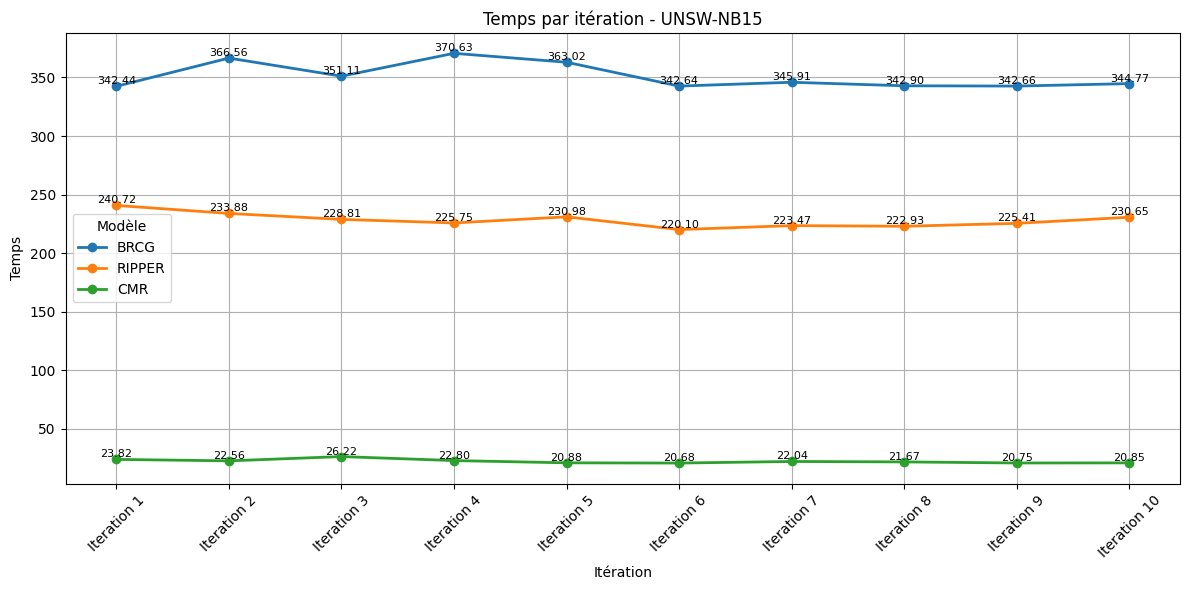

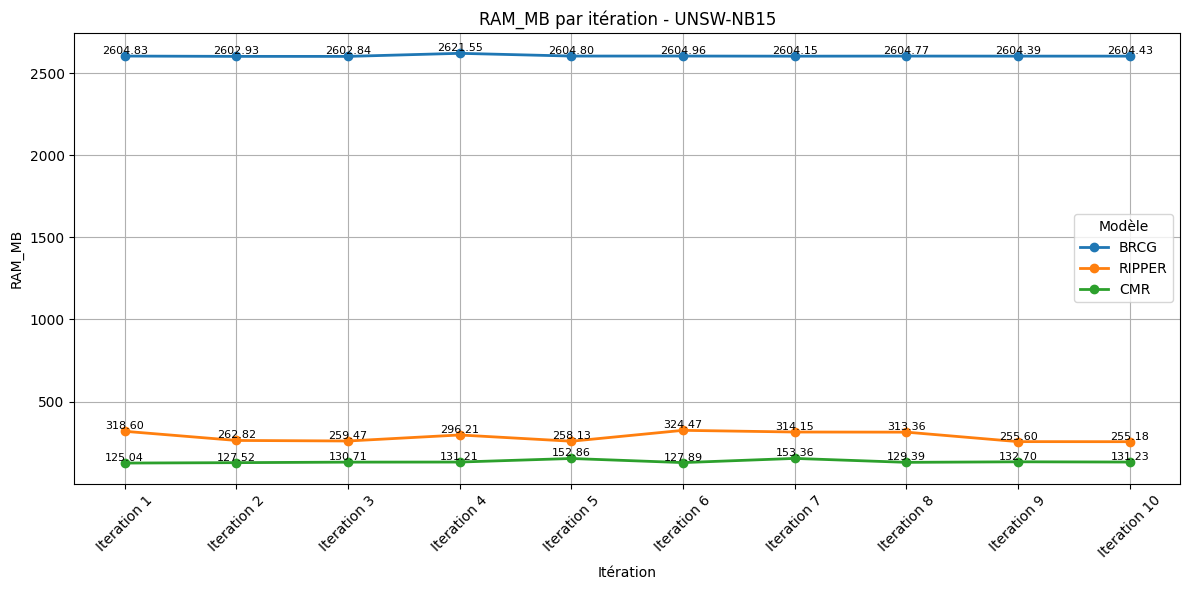

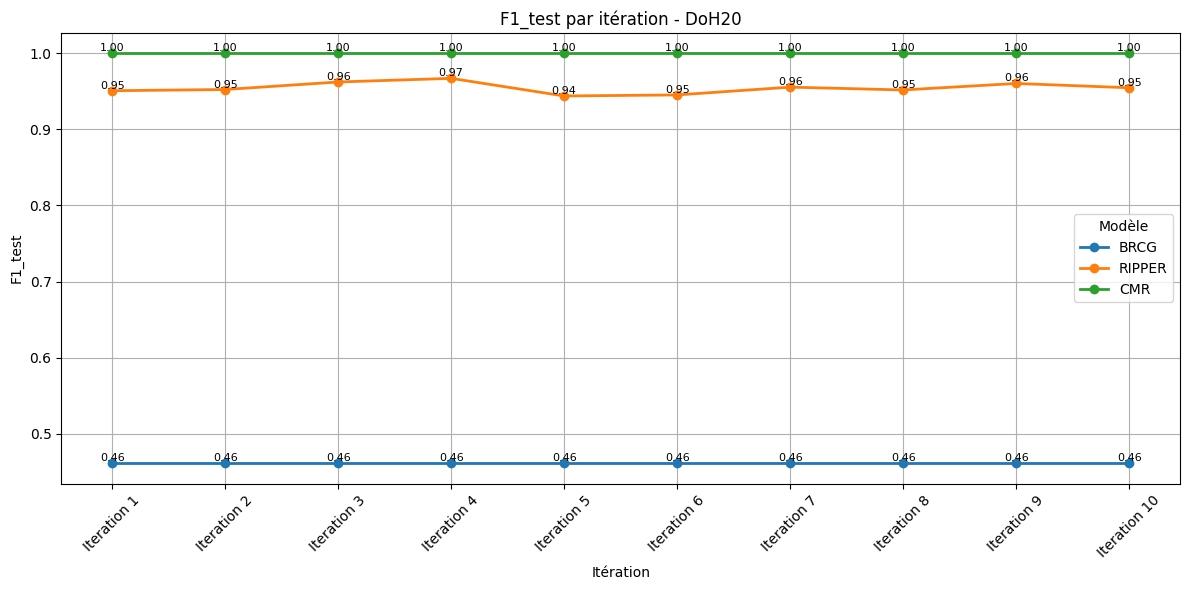

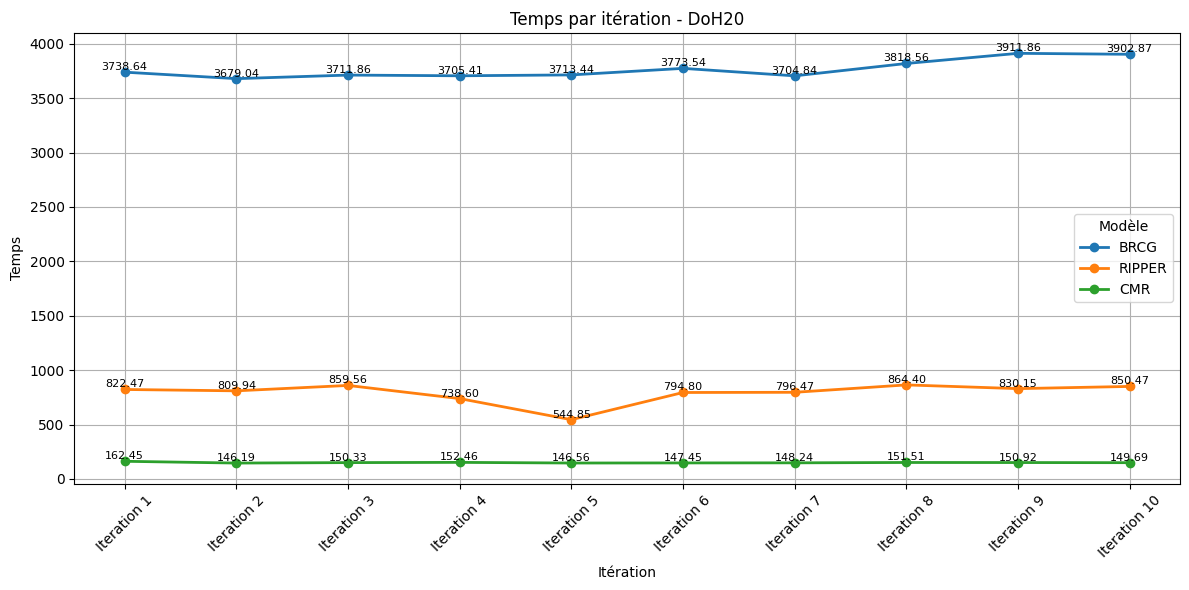

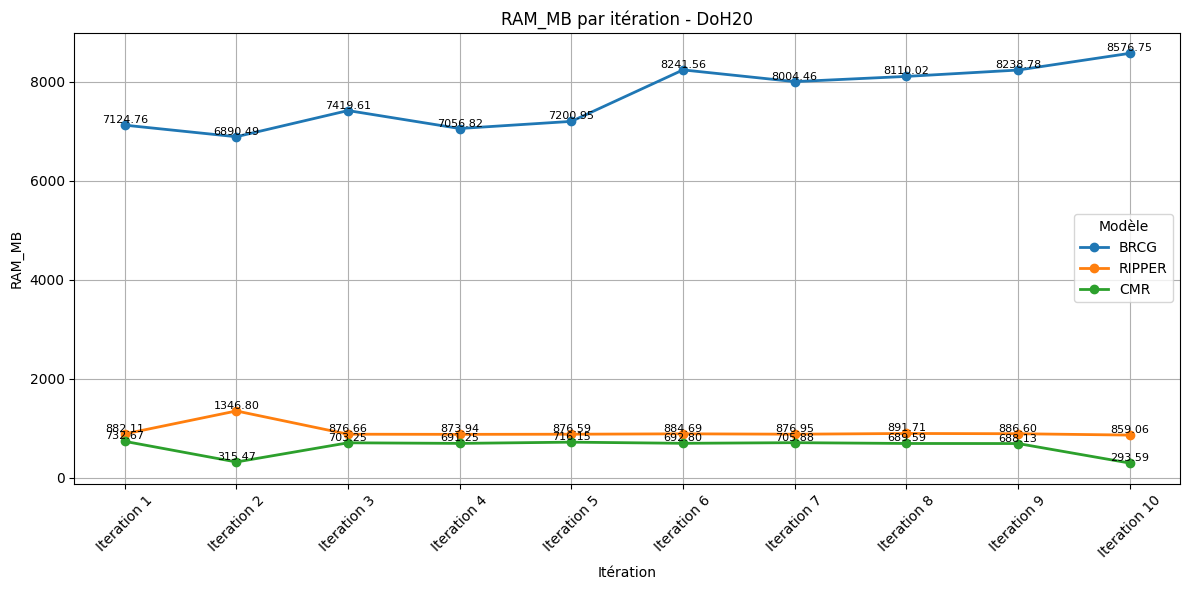

In [27]:
df = pd.read_csv("progress_iterations_10.csv")

df["Iteration"] = pd.to_numeric(df["Iteration"], errors="coerce")

metrics = ["F1_test", "Temps", "RAM_MB"]

colors = {
    "BRCG": "#1f77b4",
    "RIPPER": "#ff7f0e",
    "CMR": "#2ca02c"
}

datasets = df["Dataset"].unique()

for dataset in datasets:
    df_dataset = df[df["Dataset"] == dataset].copy()

    for metric in metrics:
        plt.figure(figsize=(12, 6))

        for method in df_dataset["Méthode"].unique():
            subset = df_dataset[df_dataset["Méthode"] == method].sort_values("Iteration")

            x = subset["Iteration"]
            y = subset[metric]

            plt.plot(
                x,
                y,
                marker="o",
                linewidth=2,
                label=method,
                color=colors.get(method, None)
            )

            # afficher les valeurs
            for i, txt in enumerate(y):
                plt.text(
                    x.iloc[i],
                    y.iloc[i],
                    f"{txt:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=8
                )

        plt.title(f"{metric} par itération - {dataset}")
        plt.xlabel("Itération")
        plt.ylabel(metric)
        plt.xticks(range(1, 11), [f"Iteration {i}" for i in range(1, 11)], rotation=45)
        plt.grid(True)
        plt.legend(title="Modèle")
        plt.tight_layout()

        plt.savefig(f"{dataset}_{metric}_line_values.png", dpi=300)
        plt.show()

## 1.2 Comparaison des performances des modèles pour chaque itération

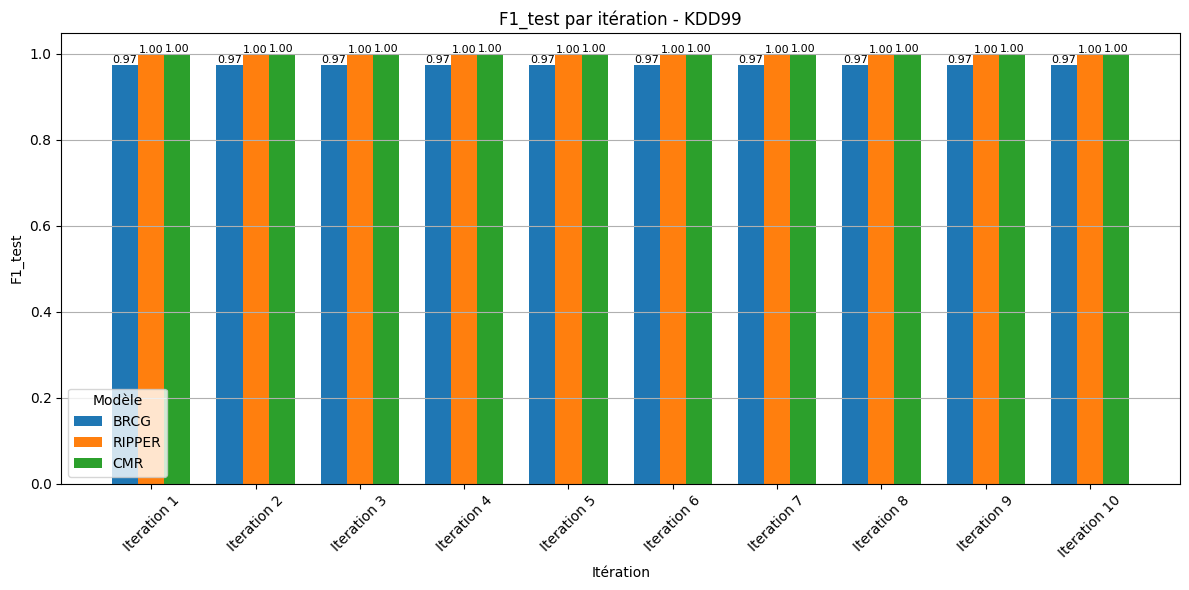

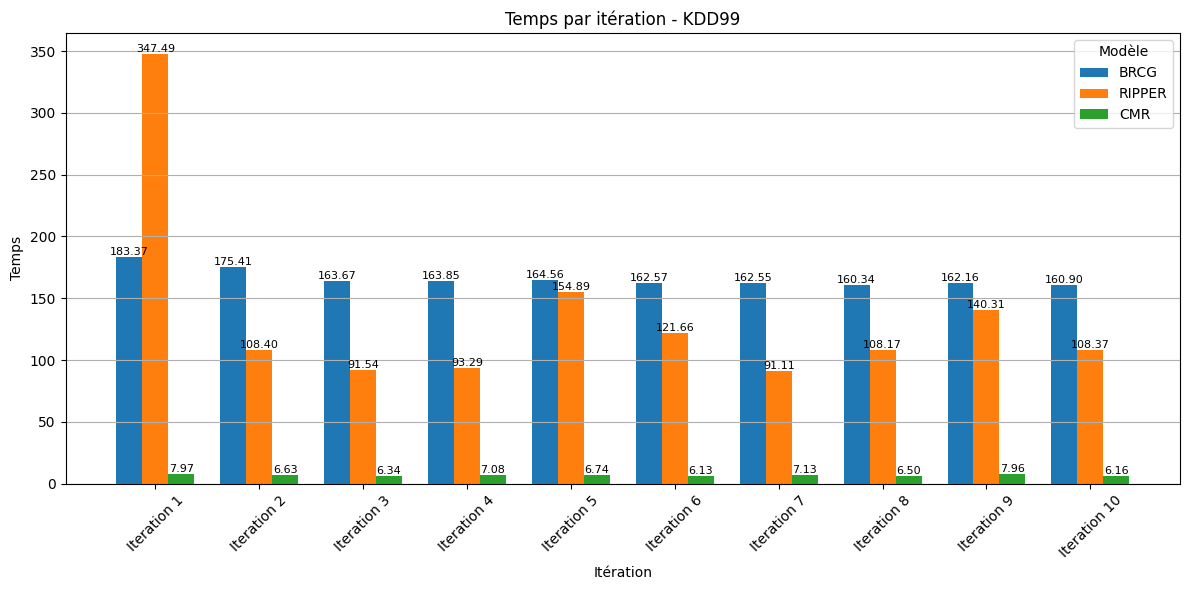

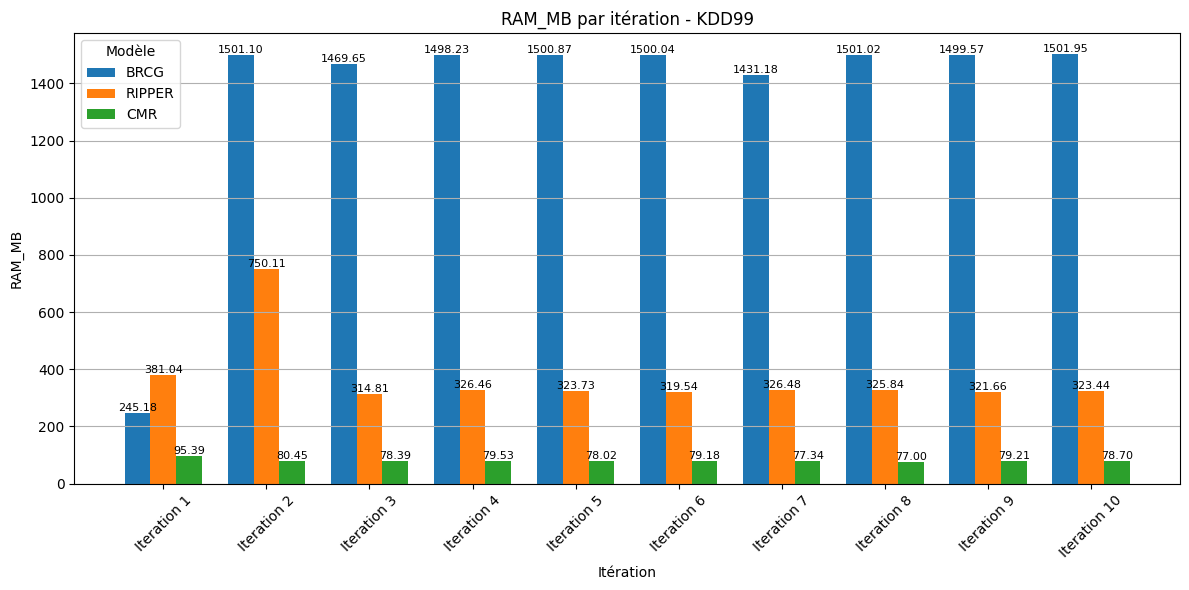

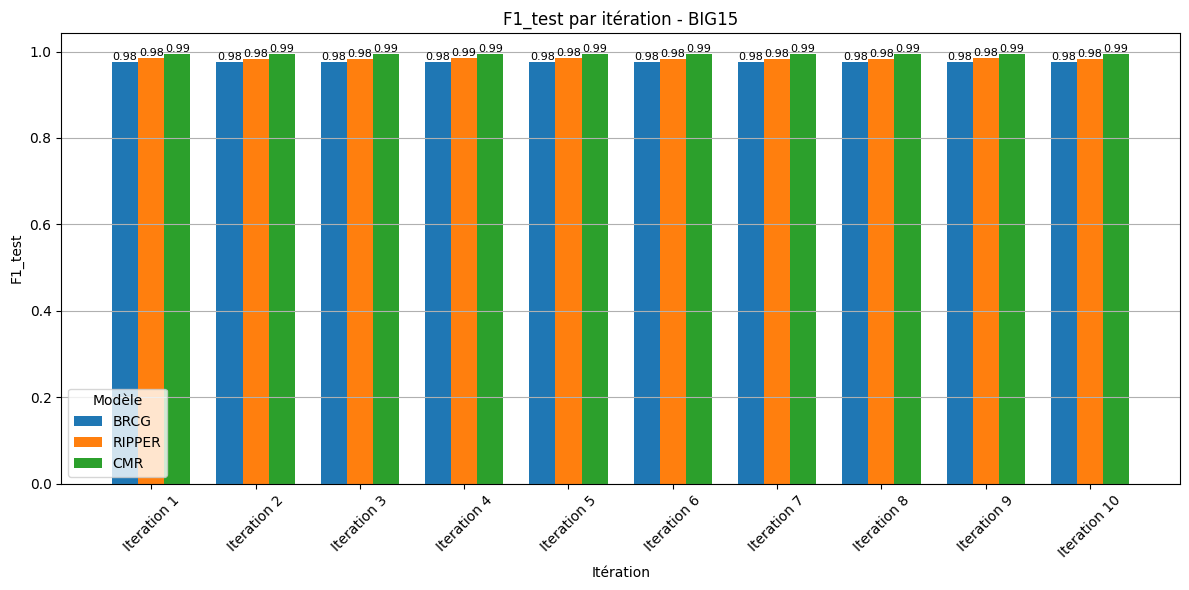

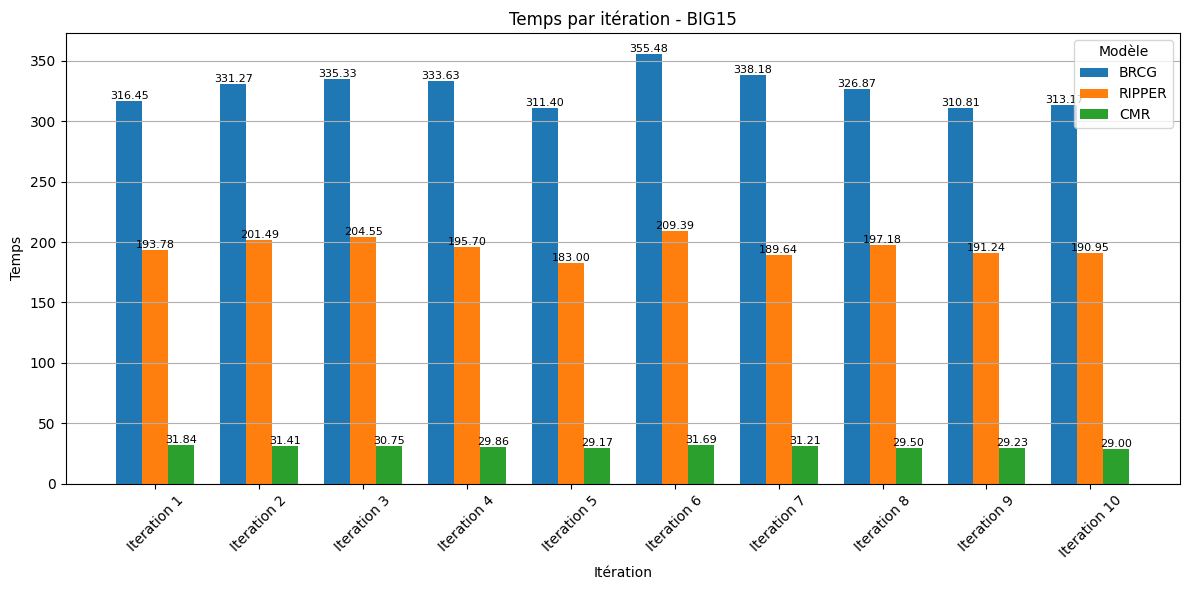

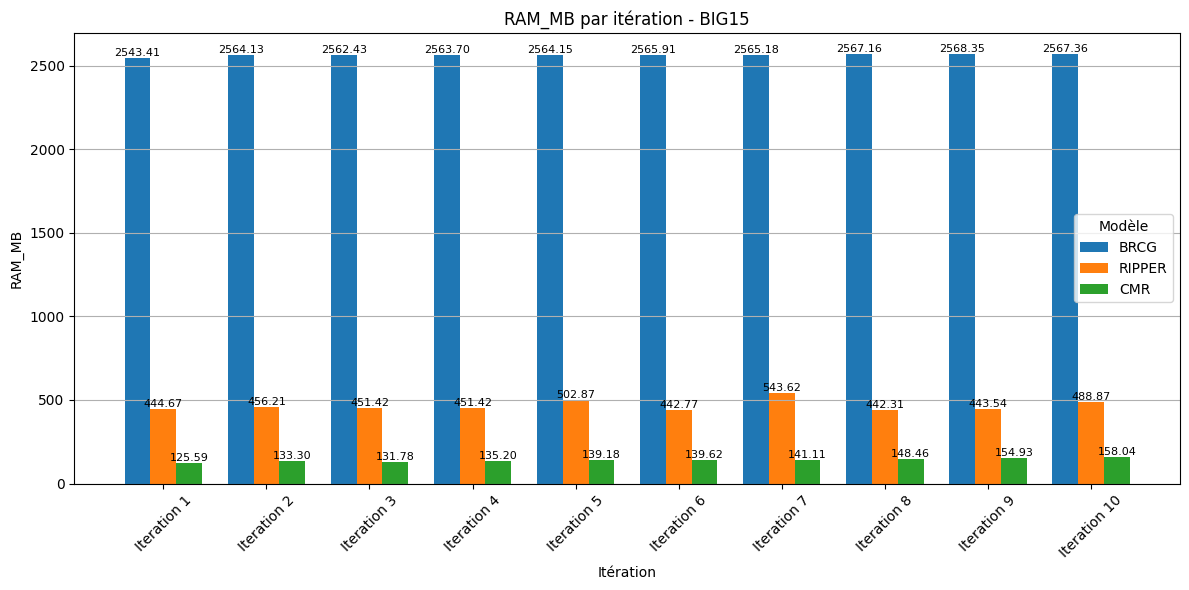

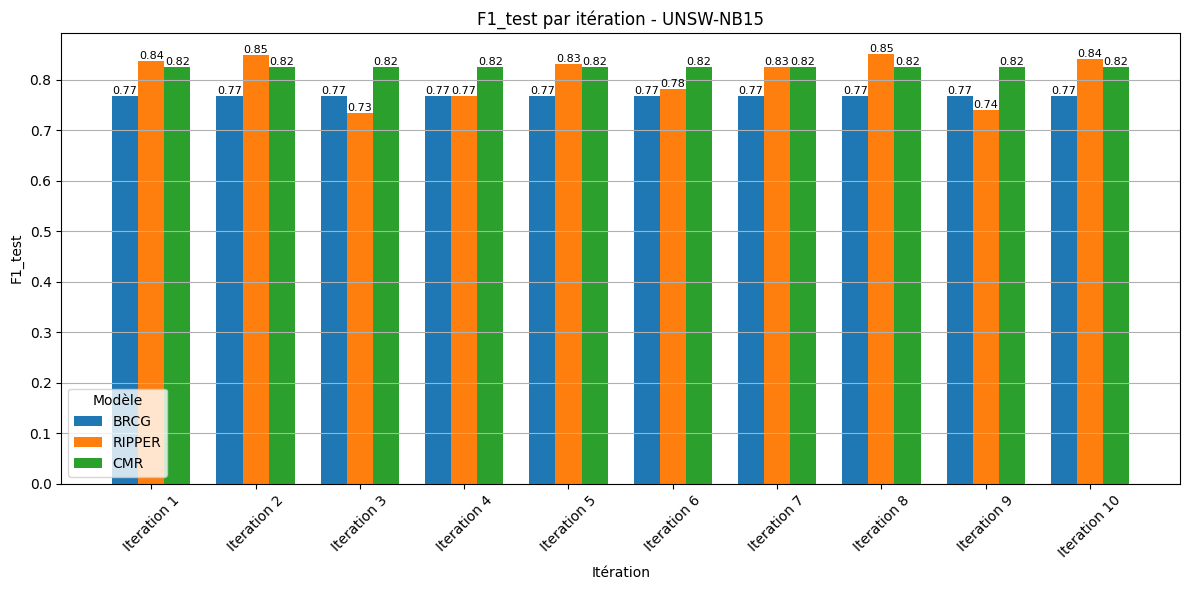

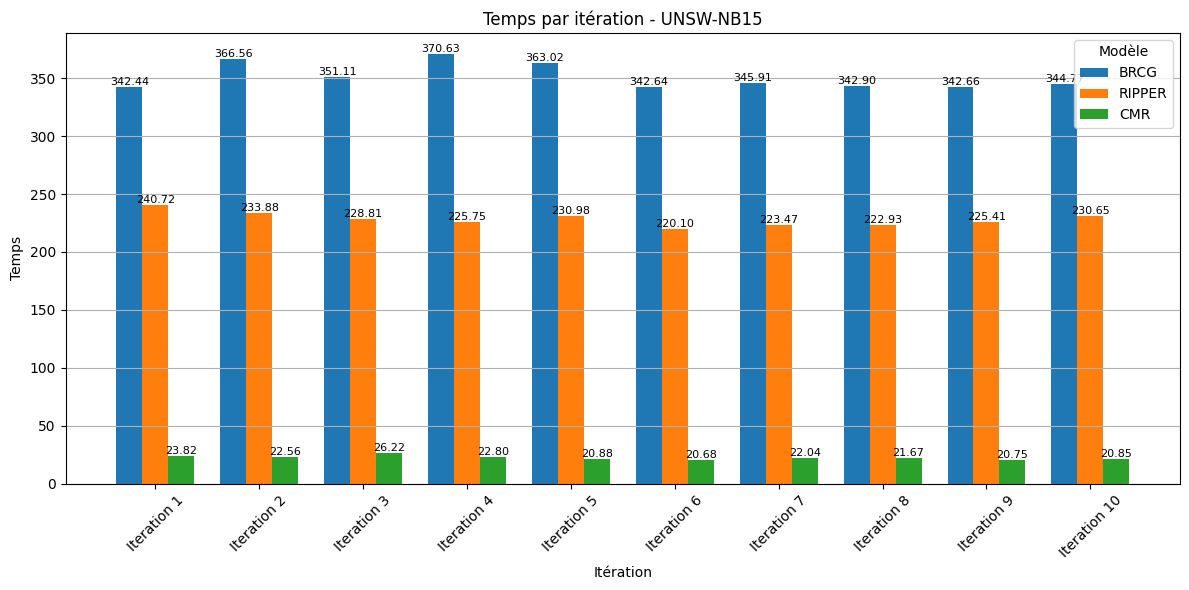

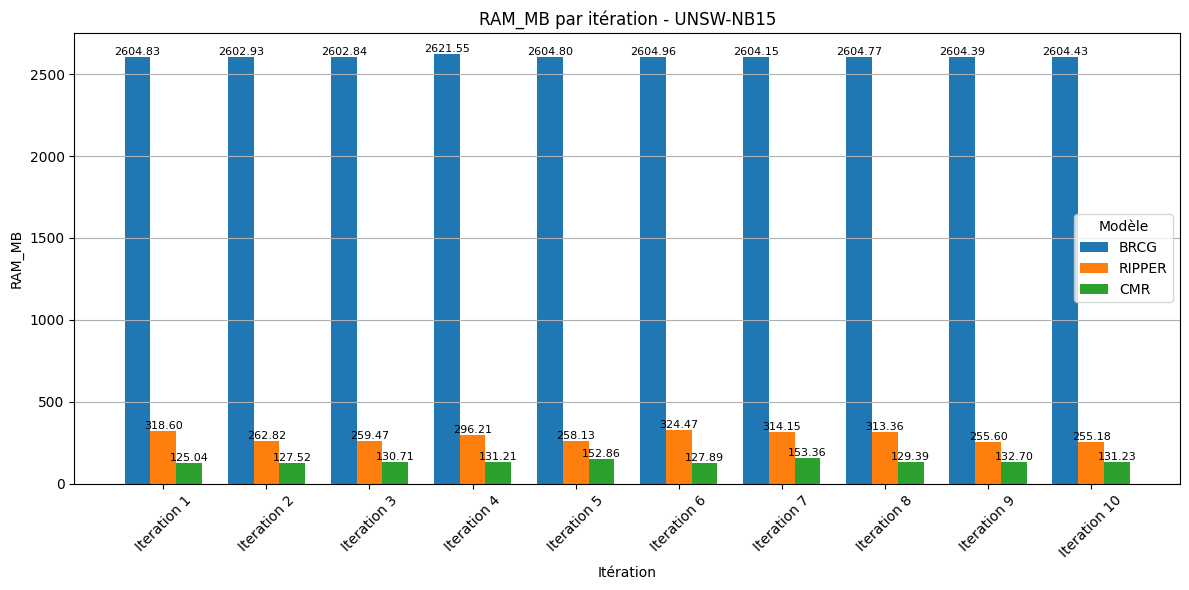

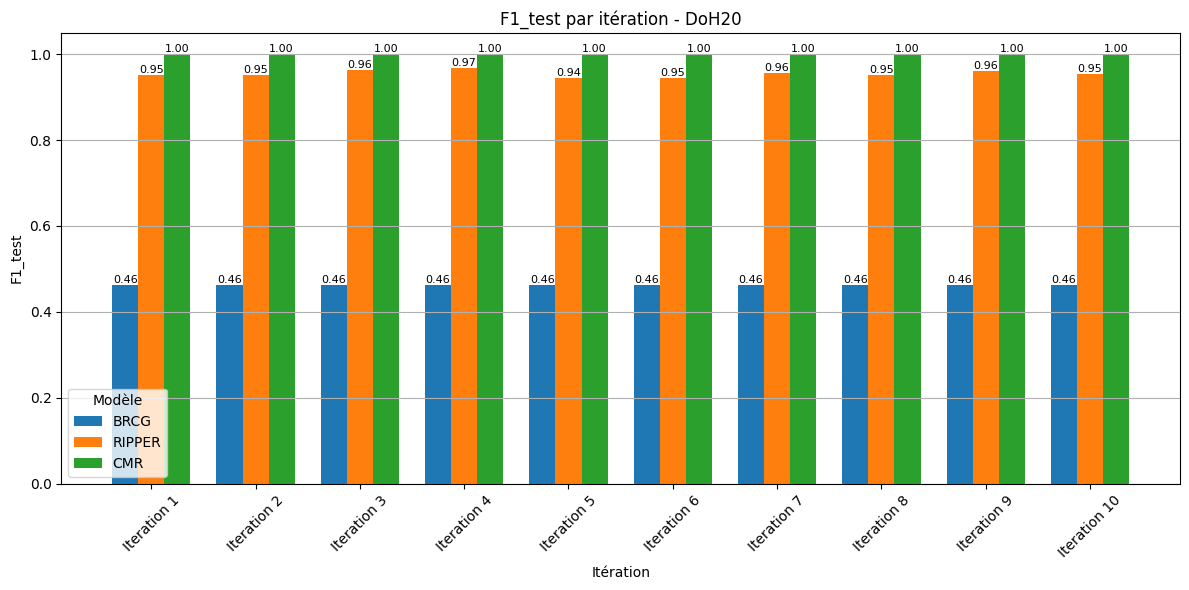

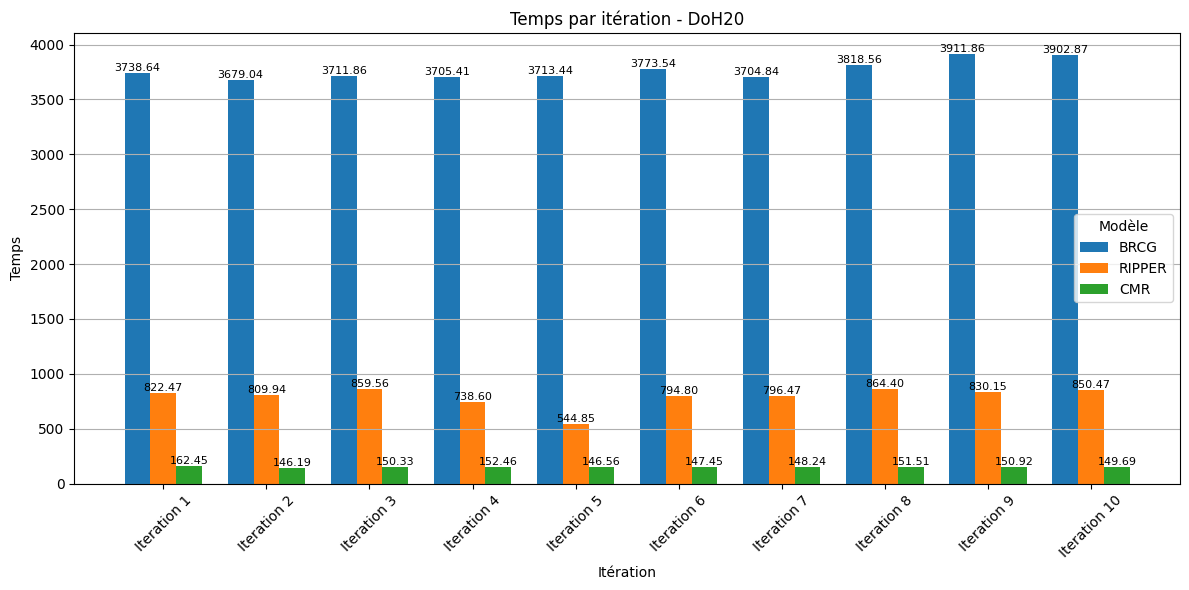

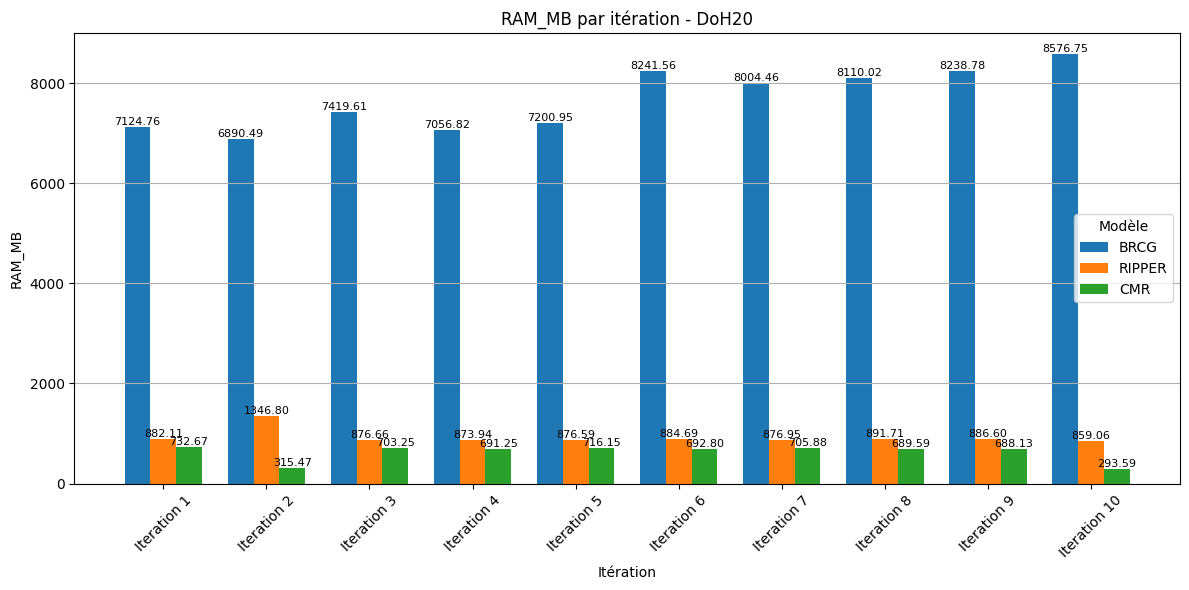

In [ ]:
df = pd.read_csv("progress_iterations_10.csv")

df["Iteration"] = pd.to_numeric(df["Iteration"], errors="coerce")

metrics = ["F1_test", "Temps", "RAM_MB"]

colors = {
    "BRCG": "#1f77b4",
    "RIPPER": "#ff7f0e",
    "CMR": "#2ca02c"
}

datasets = df["Dataset"].unique()

for dataset in datasets:
    df_dataset = df[df["Dataset"] == dataset].copy()

    methods = df_dataset["Méthode"].unique()
    iterations = sorted(df_dataset["Iteration"].dropna().unique())
    labels = [f"Iteration {int(i)}" for i in iterations]

    for metric in metrics:
        plt.figure(figsize=(12, 6))

        x = np.arange(len(iterations))
        width = 0.25

        for i, method in enumerate(methods):
            subset = df_dataset[df_dataset["Méthode"] == method].sort_values("Iteration")

            subset = subset.set_index("Iteration").reindex(iterations).reset_index()

            y = subset[metric].values

            bars = plt.bar(
                x + i * width,
                y,
                width=width,
                label=method,
                color=colors.get(method, None)
            )

            # afficher valeurs au-dessus des barres
            for bar in bars:
                height = bar.get_height()
                plt.text(
                    bar.get_x() + bar.get_width() / 2,
                    height,
                    f"{height:.2f}",
                    ha='center',
                    va='bottom',
                    fontsize=8
                )

        plt.title(f"{metric} par itération - {dataset}")
        plt.xlabel("Itération")
        plt.ylabel(metric)
        plt.xticks(x + width, labels, rotation=45)
        plt.grid(axis="y")
        plt.legend(title="Modèle")
        plt.tight_layout()

        plt.savefig(f"{dataset}_{metric}_bar_values.png", dpi=300)
        plt.show()

# 2 Moyennes

## 2.1 Comparaison des performances moyennes des modèles

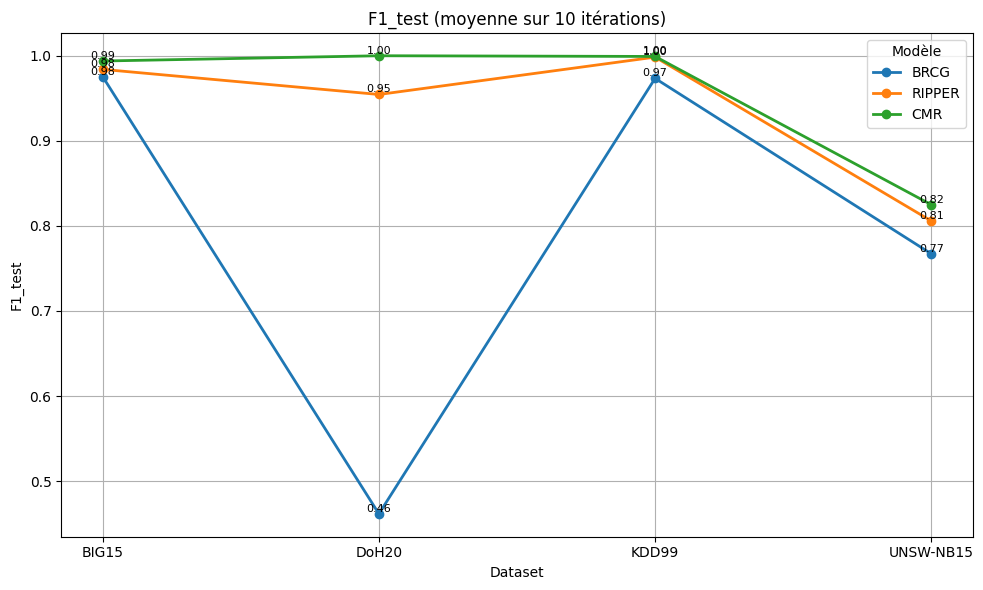

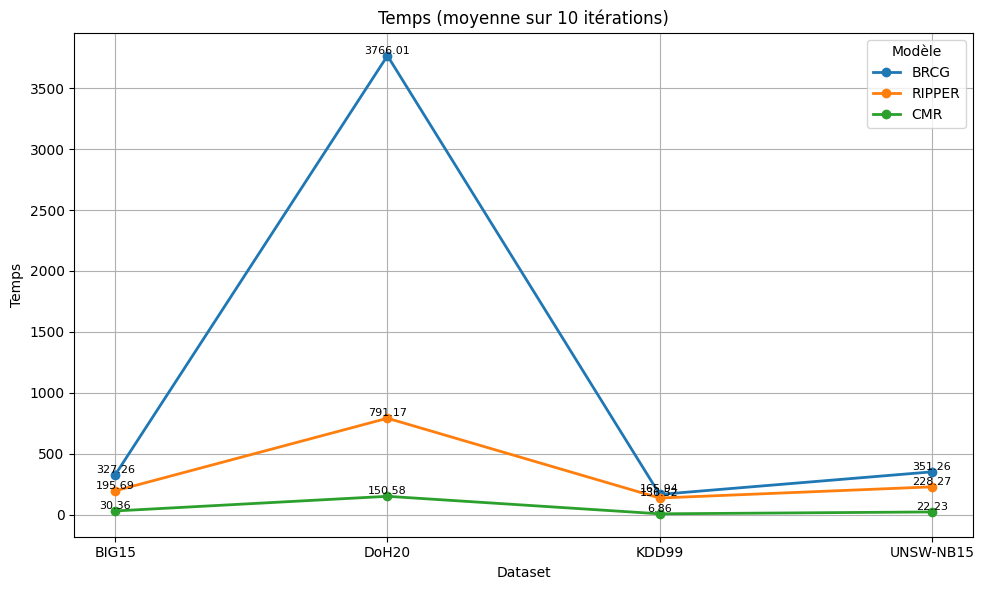

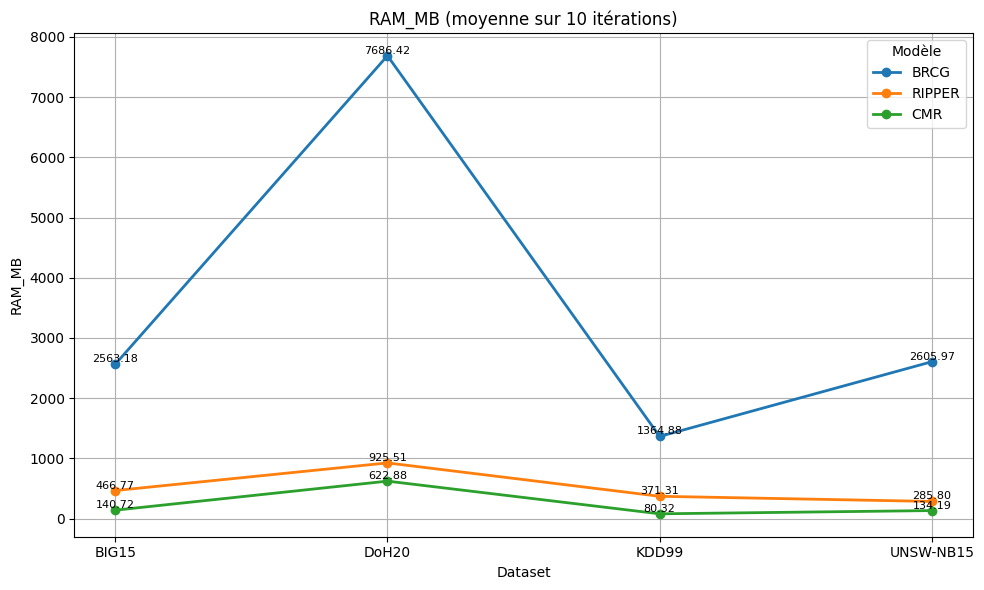

In [14]:
# Charger le fichier
df = pd.read_csv("tableau_comparatif_10.csv")

metrics = ["F1_test", "Temps", "RAM_MB"]

colors = {
    "BRCG": "#1f77b4",
    "RIPPER": "#ff7f0e",
    "CMR": "#2ca02c"
}

for metric in metrics:
    plt.figure(figsize=(10,6))

    for method in df["Méthode"].unique():
        subset = df[df["Méthode"] == method]

        plt.plot(
            subset["Dataset"],
            subset[metric],
            marker="o",
            linewidth=2,
            label=method,
            color=colors.get(method, None)
        )

        # afficher les valeurs
        for i in range(len(subset)):
            plt.text(
                subset["Dataset"].iloc[i],
                subset[metric].iloc[i],
                f"{subset[metric].iloc[i]:.2f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

    plt.title(f"{metric} (moyenne sur 10 itérations)")
    plt.xlabel("Dataset")
    plt.ylabel(metric)
    plt.grid(True)
    plt.legend(title="Modèle")
    plt.tight_layout()

    plt.savefig(f"{metric}_mean_line.png", dpi=300)
    plt.show()

## 2.2 Comparaison des performances moyennes des modèles (diagramme en barres)

<Figure size 1000x600 with 0 Axes>

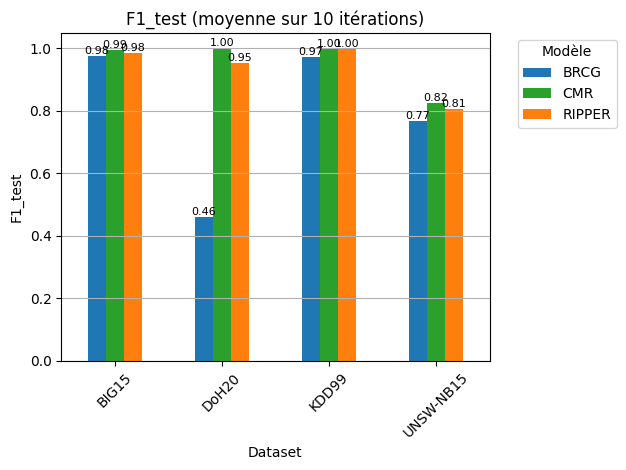

<Figure size 1000x600 with 0 Axes>

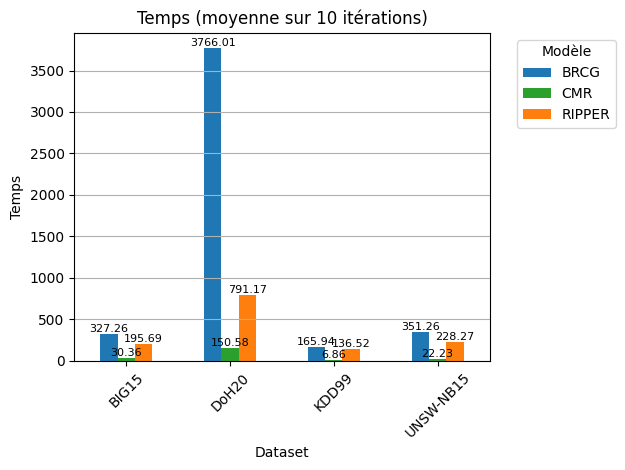

<Figure size 1000x600 with 0 Axes>

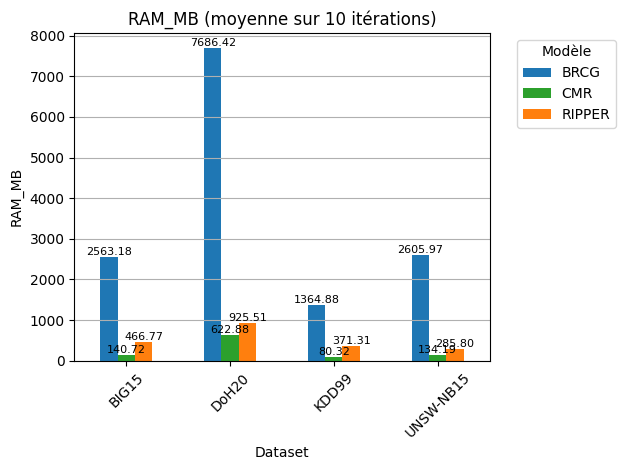

In [25]:
for metric in metrics:
    pivot = df.pivot(index="Dataset", columns="Méthode", values=metric)

    plt.figure(figsize=(10,6))

    ax = pivot.plot(
        kind="bar",
        color=[colors.get(col, "#333333") for col in pivot.columns]
    )

    plt.title(f"{metric} (moyenne sur 10 itérations)")
    plt.xlabel("Dataset")
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.grid(axis="y")

    # afficher valeurs au-dessus des barres
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height,
                f"{height:.2f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

    plt.legend(title="Modèle", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    plt.savefig(f"{metric}_mean_bar.png", dpi=300)
    plt.show()

        Dataset Méthode  Sample_Size   F1_test        Temps       RAM_MB  \
0   CIC2017_25k    BRCG        25000  0.860065   648.630000   360.710000   
1   CIC2017_25k  RIPPER        25000  0.995793    92.070000   637.840000   
2   CIC2017_25k     CMR        25000  0.997473   392.772656  1063.738281   
3   CIC2017_50k    BRCG        50000  0.940934   753.950000   446.660000   
4   CIC2017_50k  RIPPER        50000  0.996849   155.040000   721.170000   
5   CIC2017_50k     CMR        50000  0.997774   200.178662  2064.660156   
6  CIC2017_100k    BRCG       100000  0.917734  2229.880000   552.100000   
7  CIC2017_100k  RIPPER       100000  0.997151   321.450000   951.980000   
8  CIC2017_100k     CMR       100000  0.998084   637.777432  1539.968750   

   Complexité  
0         1.0  
1        34.0  
2     15953.0  
3         1.0  
4        37.0  
5     27908.0  
6         1.0  
7        38.0  
8     51950.0  


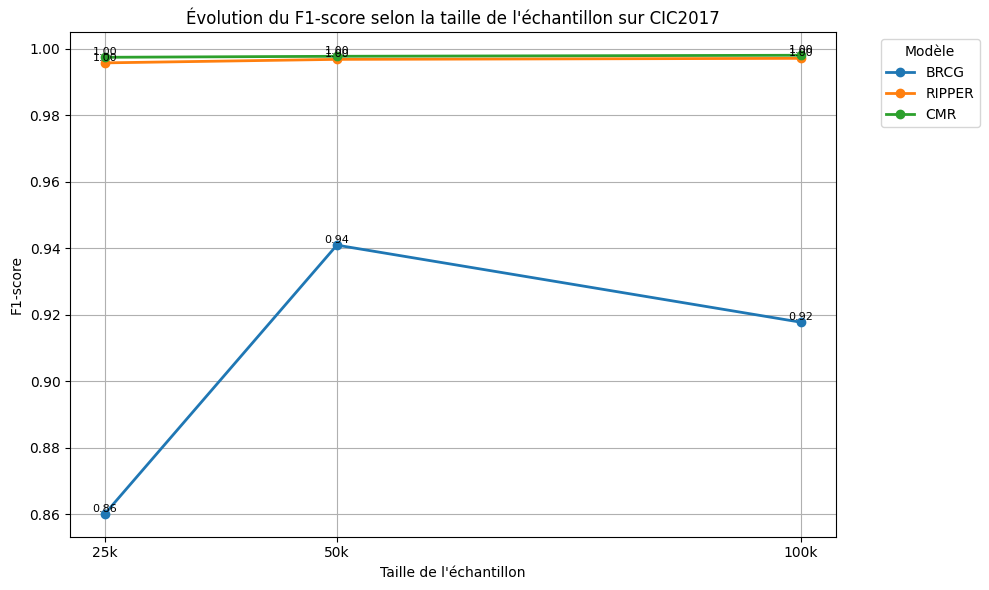

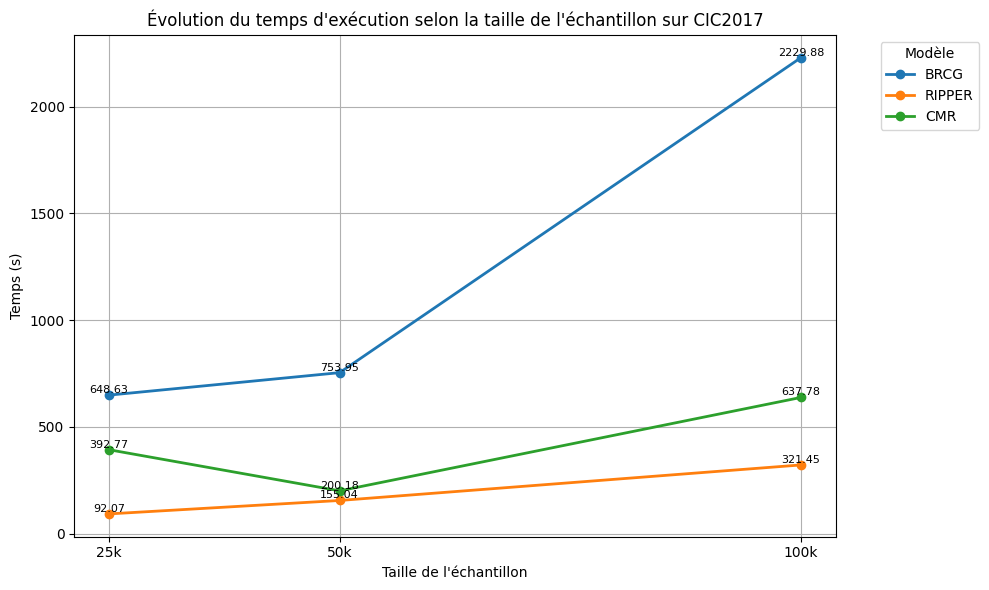

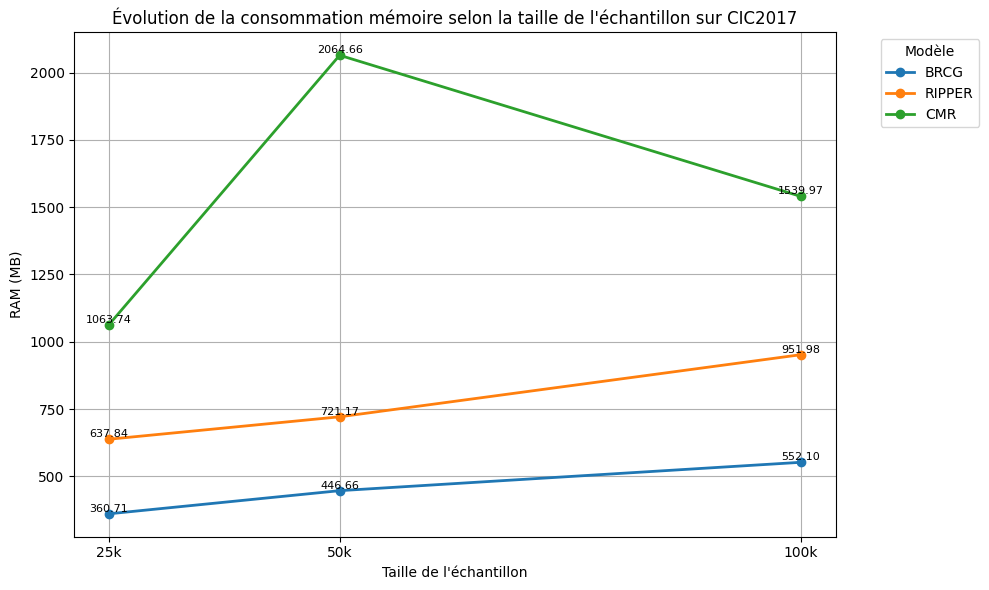

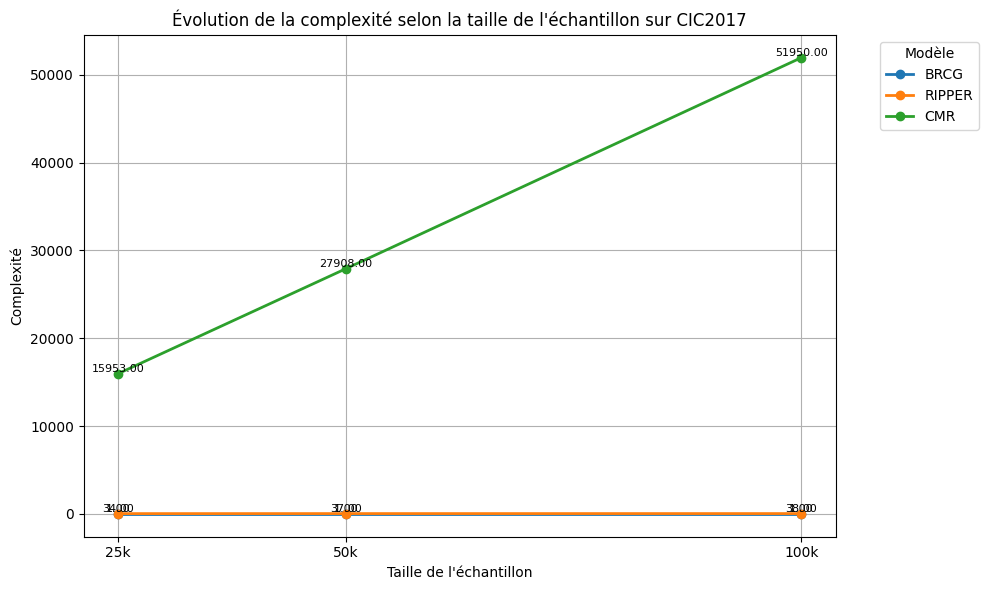

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger les fichiers de sortie
df_25k = pd.read_csv("tableau_comparatif_cic2017_25k.csv")
df_50k = pd.read_csv("tableau_comparatif_cic2017_50k.csv")
df_100k = pd.read_csv("tableau_comparatif_cic2017_100k.csv")

# Ajouter une colonne pour la taille de l'échantillon
df_25k["Sample_Size"] = 25000
df_50k["Sample_Size"] = 50000
df_100k["Sample_Size"] = 100000

# Fusionner les trois tableaux
df_all = pd.concat([df_25k, df_50k, df_100k], ignore_index=True)

# Vérification
print(df_all[["Dataset", "Méthode", "Sample_Size", "F1_test", "Temps", "RAM_MB", "Complexité"]])

colors = {
    "BRCG": "#1f77b4",
    "RIPPER": "#ff7f0e",
    "CMR": "#2ca02c"
}

metrics = ["F1_test", "Temps", "RAM_MB", "Complexité"]

titles = {
    "F1_test": "Évolution du F1-score selon la taille de l'échantillon sur CIC2017",
    "Temps": "Évolution du temps d'exécution selon la taille de l'échantillon sur CIC2017",
    "RAM_MB": "Évolution de la consommation mémoire selon la taille de l'échantillon sur CIC2017",
    "Complexité": "Évolution de la complexité selon la taille de l'échantillon sur CIC2017"
}

ylabels = {
    "F1_test": "F1-score",
    "Temps": "Temps (s)",
    "RAM_MB": "RAM (MB)",
    "Complexité": "Complexité"
}

# Graphes en courbes
for metric in metrics:
    plt.figure(figsize=(10, 6))

    for method in df_all["Méthode"].unique():
        subset = df_all[df_all["Méthode"] == method].sort_values("Sample_Size")

        plt.plot(
            subset["Sample_Size"],
            subset[metric],
            marker="o",
            linewidth=2,
            label=method,
            color=colors.get(method, None)
        )

        for _, row in subset.iterrows():
            plt.text(
                row["Sample_Size"],
                row[metric],
                f"{row[metric]:.2f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

    plt.title(titles[metric])
    plt.xlabel("Taille de l'échantillon")
    plt.ylabel(ylabels[metric])
    plt.xticks([25000, 50000, 100000], ["25k", "50k", "100k"])
    plt.grid(True)
    plt.legend(title="Modèle", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(f"CIC2017_{metric}_line.png", dpi=300)
    plt.show()

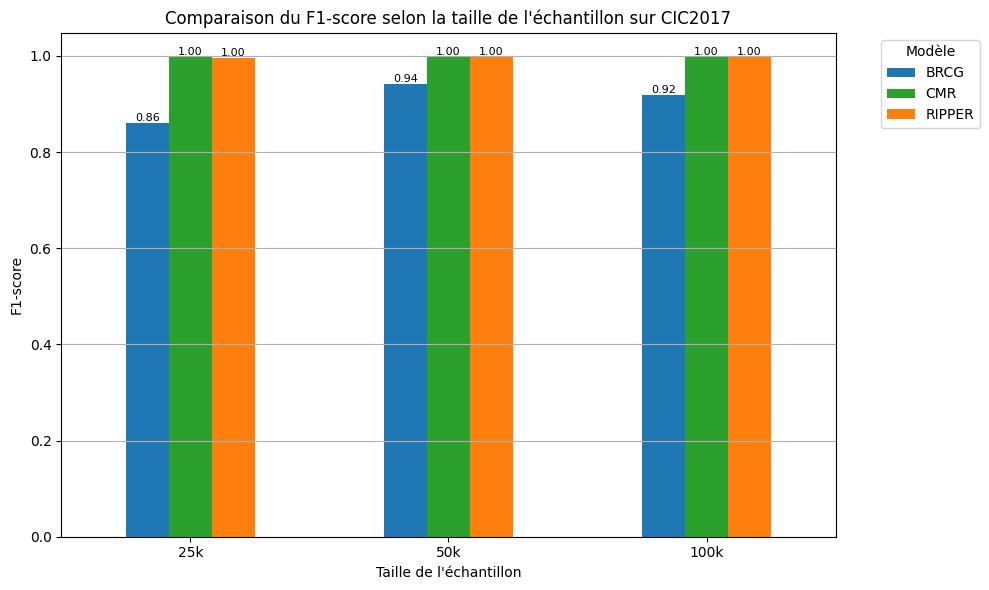

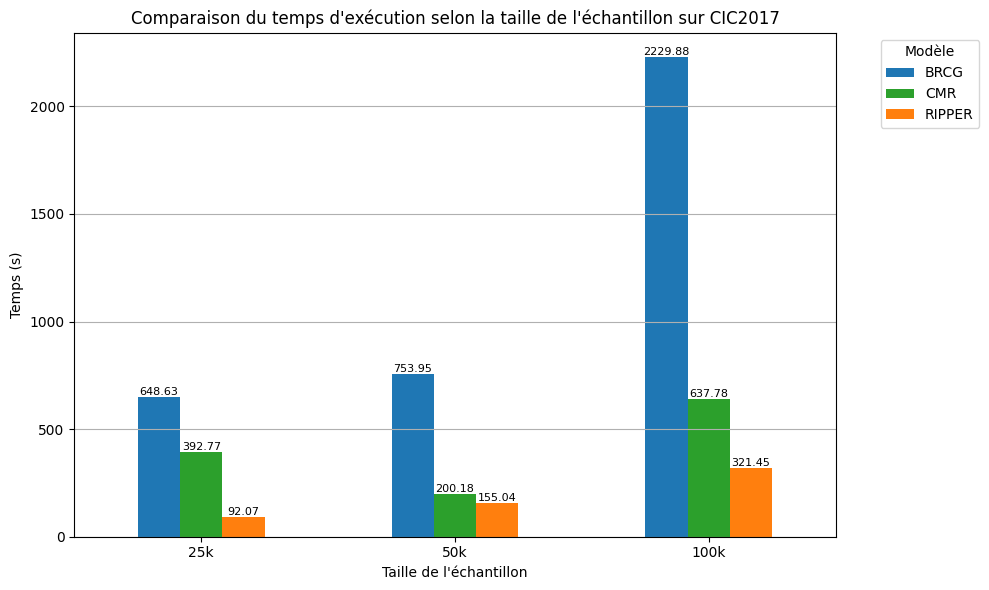

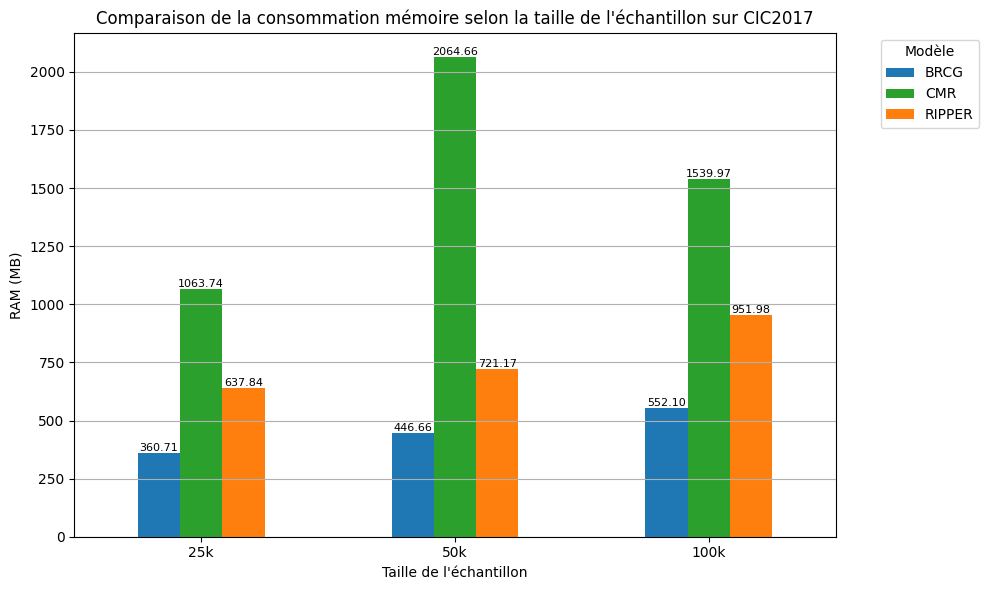

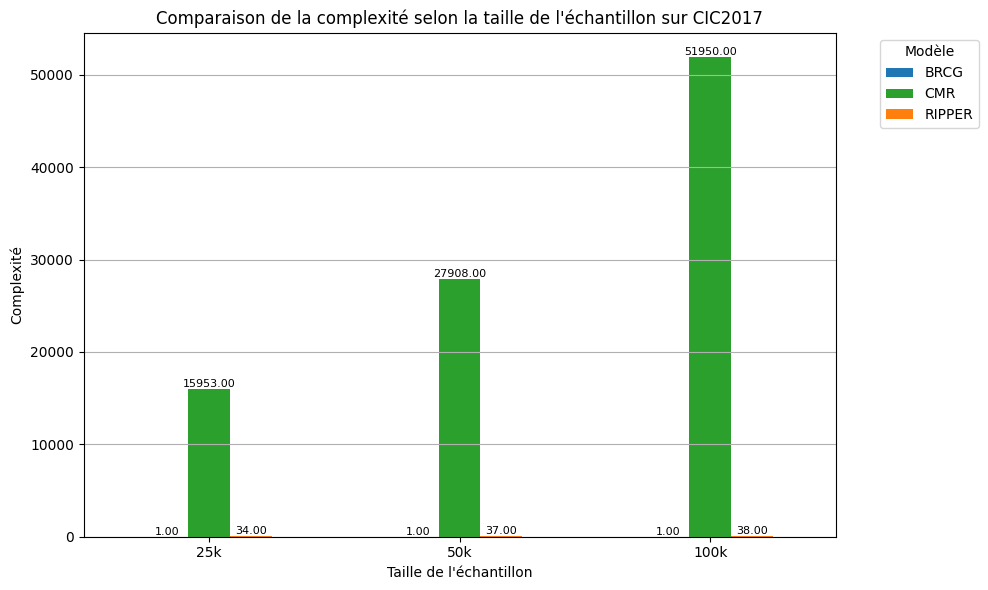

In [2]:
import numpy as np

for metric in metrics:
    pivot = df_all.pivot(index="Sample_Size", columns="Méthode", values=metric)

    ax = pivot.plot(
        kind="bar",
        figsize=(10, 6),
        color=[colors.get(col, "#333333") for col in pivot.columns]
    )

    plt.title(titles[metric].replace("Évolution", "Comparaison"))
    plt.xlabel("Taille de l'échantillon")
    plt.ylabel(ylabels[metric])
    plt.xticks(rotation=0)
    ax.set_xticklabels(["25k", "50k", "100k"])
    plt.grid(axis="y")
    plt.legend(title="Modèle", bbox_to_anchor=(1.05, 1), loc="upper left")

    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if pd.notna(height):
                plt.text(
                    bar.get_x() + bar.get_width() / 2,
                    height,
                    f"{height:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=8
                )

    plt.tight_layout()
    plt.savefig(f"CIC2017_{metric}_bar.png", dpi=300)
    plt.show()

### sample 25k CIC2017 10 iteration


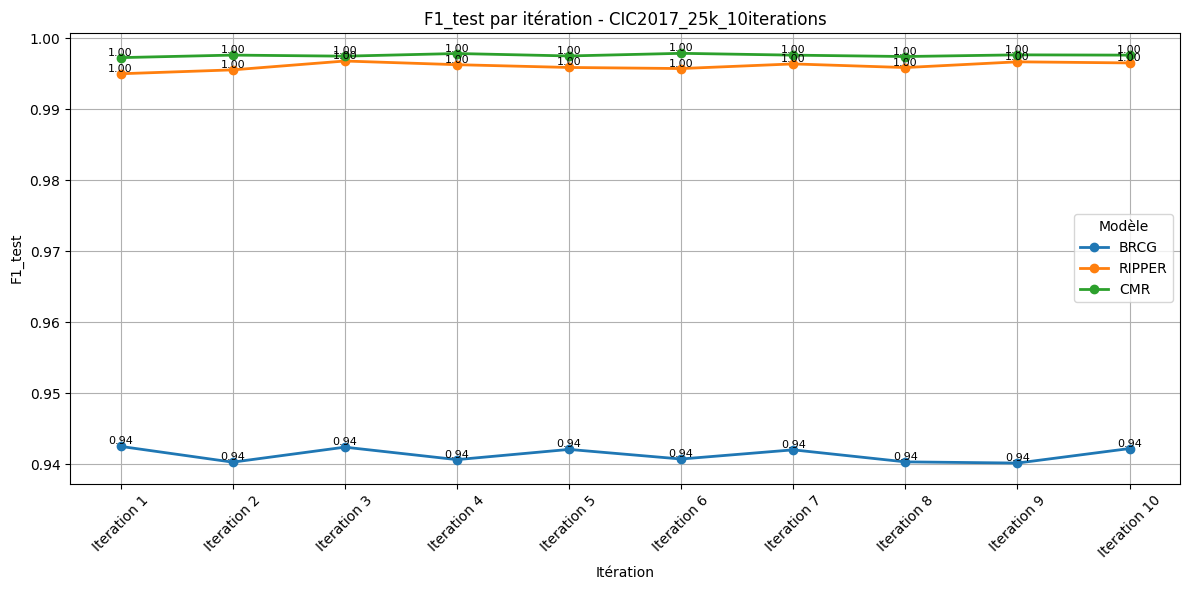

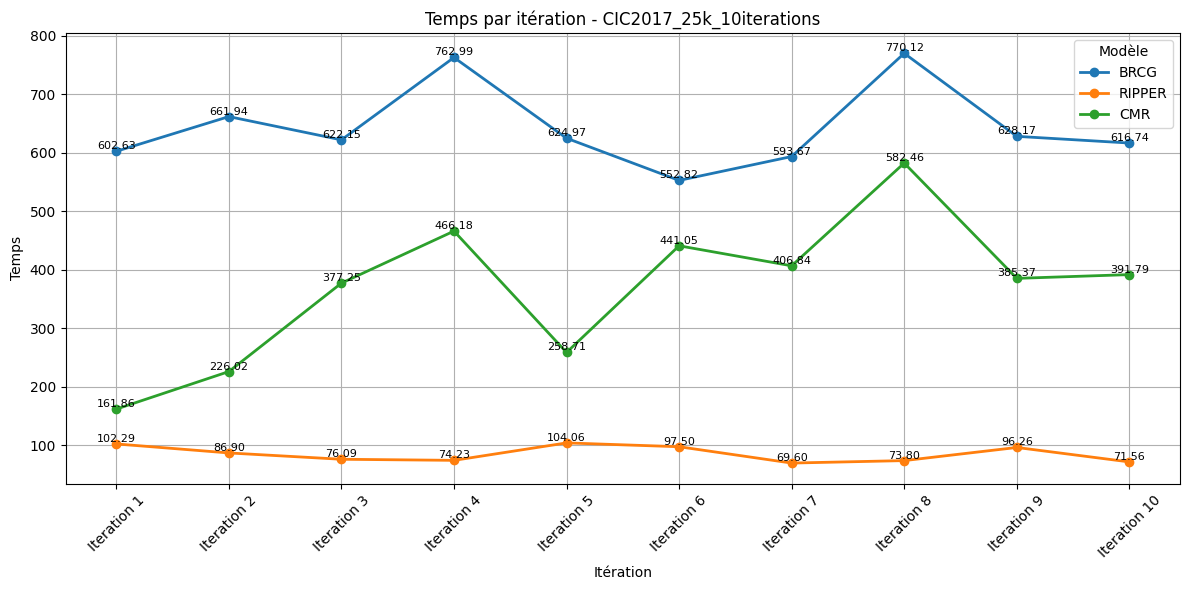

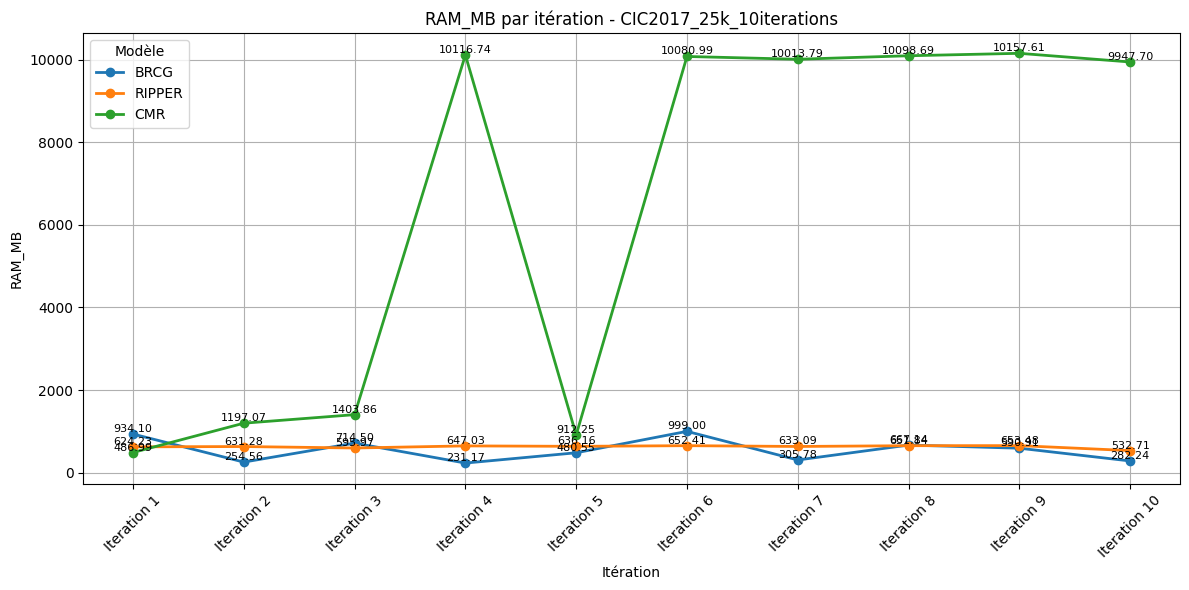

In [2]:
df = pd.read_csv("progress_iterations_cic2017_25k_10iterations.csv")

df["Iteration"] = pd.to_numeric(df["Iteration"], errors="coerce")

metrics = ["F1_test", "Temps", "RAM_MB"]

colors = {
    "BRCG": "#1f77b4",
    "RIPPER": "#ff7f0e",
    "CMR": "#2ca02c"
}

datasets = df["Dataset"].unique()

for dataset in datasets:
    df_dataset = df[df["Dataset"] == dataset].copy()

    for metric in metrics:
        plt.figure(figsize=(12, 6))

        for method in df_dataset["Méthode"].unique():
            subset = df_dataset[df_dataset["Méthode"] == method].sort_values("Iteration")

            x = subset["Iteration"]
            y = subset[metric]

            plt.plot(
                x,
                y,
                marker="o",
                linewidth=2,
                label=method,
                color=colors.get(method, None)
            )

            # afficher les valeurs
            for i, txt in enumerate(y):
                plt.text(
                    x.iloc[i],
                    y.iloc[i],
                    f"{txt:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=8
                )

        plt.title(f"{metric} par itération - {dataset}")
        plt.xlabel("Itération")
        plt.ylabel(metric)
        plt.xticks(range(1, 11), [f"Iteration {i}" for i in range(1, 11)], rotation=45)
        plt.grid(True)
        plt.legend(title="Modèle")
        plt.tight_layout()

        plt.savefig(f"{dataset}_{metric}_line_values.png", dpi=300)
        plt.show()